# 02 — Pré-processamento e seleção de atributos

Cada decisão vem com sua justificativa escrita. Ordem do notebook:

1. Dados faltantes
2. Definição da variável alvo
3. Limpeza (IDs repetidos, coluna constante, valor-código de emprego)
4. Feature engineering
5. Normalização
6. Seleção de atributos
7. Grupos de perfil (para a validação sem vazamento)
8. Salvar o dataset tratado

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

from src.config import DAYS_EMPLOYED_SENTINEL, GROUP, METRICS, PROCESSED_FILE, TARGET
from src.data import load_application, load_credit, save_processed
from src.preprocessing import build_features, build_target, check_missing, drop_duplicated_ids, profile_groups
from src.viz import COR_BOM, COR_MAU, COR_NEUTRA, aplicar_estilo, salvar

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
aplicar_estilo()

In [2]:
app = load_application()
credit = load_credit()
app.shape, credit.shape

((438557, 18), (1048575, 3))

## 1. Dados faltantes

In [3]:
check_missing(app)

,nulos,pct
OCCUPATION_TYPE,134203,30.6


In [4]:
check_missing(credit)

,nulos,pct


**Decisão:** só `OCCUPATION_TYPE` tem nulos (30,6% do cadastro). O histórico de crédito não tem nenhum.

- **Excluir as linhas** jogaria fora quase um terço dos solicitantes.
- **Imputar a moda** (*Laborers*) inventaria uma profissão para 134 mil pessoas.
- **Escolha:** criar a categoria `Nao informado`. Ela preserva todas as linhas e deixa o modelo
  aprender se "não declarar a ocupação" carrega risco. Na EDA, esse grupo teve 1,7% de maus,
  exatamente a média. A transformação é feita em `build_features` (seção 4).

## 2. Definição da variável alvo

O `credit_record` traz, para cada cliente e cada mês, um `STATUS` de pagamento:
`C` = quitado, `X` = sem uso, `0` = 1–29 dias de atraso, `1` = 30–59, `2` = 60–89, `3` = 90–119,
`4` = 120–149, `5` = 150+ dias ou baixa como perda.

Para ter **um rótulo por cliente**, olhamos o **pior atraso** registrado em todo o histórico.

In [5]:
gravidade = {"X": -1, "C": -1, "0": 0, "1": 1, "2": 2, "3": 3, "4": 4, "5": 5}
pior = credit["STATUS"].map(gravidade).groupby(credit["ID"]).max()
nomes = {-1: "nunca atrasou", 0: "1-29 dias", 1: "30-59 dias", 2: "60-89 dias",
         3: "90-119 dias", 4: "120-149 dias", 5: "150+ dias"}
dist = pior.value_counts().sort_index().rename(index=nomes)

limiares = pd.DataFrame({
    "limiar": ["atraso >= 30 dias", "atraso >= 60 dias", "atraso >= 90 dias"],
    "% de maus": [(pior >= k).mean() * 100 for k in (1, 2, 3)],
}).round(2)
display(dist.to_frame("clientes"))
limiares

,clientes
STATUS,
nunca atrasou,5953
1-29 dias,34682
30-59 dias,4683
60-89 dias,336
90-119 dias,88
120-149 dias,48
150+ dias,195


,limiar,% de maus
0,atraso >= 30 dias,11.63
1,atraso >= 60 dias,1.45
2,atraso >= 90 dias,0.72


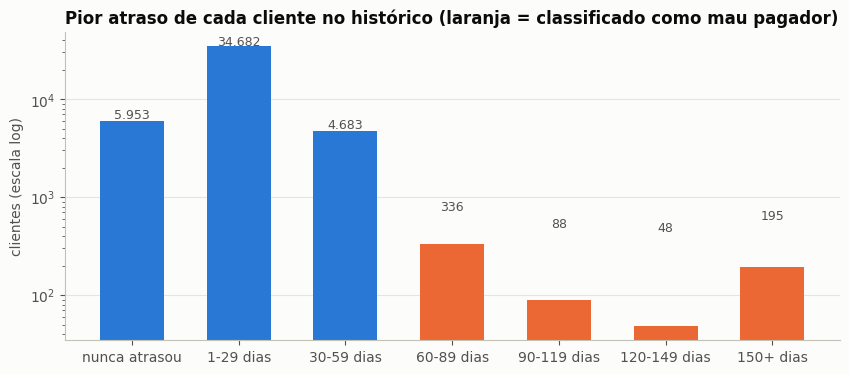

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
cores = [COR_MAU if k >= 2 else COR_BOM for k in sorted(pior.unique())]
ax.bar(dist.index, dist.values, color=cores, width=0.6)
for x, v in enumerate(dist.values):
    ax.text(x, v + 400, f"{v:,}".replace(",", "."), ha="center", fontsize=9, color="#52514e")
ax.set_yscale("log")
ax.set_ylabel("clientes (escala log)")
ax.set_title("Pior atraso de cada cliente no histórico (laranja = classificado como mau pagador)")
ax.grid(axis="x", visible=False)
salvar(fig, "02_pior_atraso")
plt.show()

**Interpretação e justificativa do limiar (60 dias):**

- A grande maioria dos clientes (75%) já teve algum atraso curto, de 1 a 29 dias. Atraso curto é
  comportamento comum, muitas vezes esquecimento ou data de vencimento. Não serve para separar
  bons de maus.
- Há uma **queda abrupta** entre 30–59 dias (4.683 clientes) e 60–89 dias (336). Passar de
  60 dias é o ponto em que o atraso deixa de ser esporádico e vira inadimplência de fato.
- **60 dias** separa 1,5% dos clientes do histórico (1,7% na base de trabalho). É o critério mais
  usado para este dataset e está alinhado à prática de mercado, que costuma tratar 60–90 dias
  como inadimplência.
- **Alternativas descartadas:** com 30 dias, 11,6% seriam "maus", misturando atrasos leves a
  inadimplentes. Com 90 dias sobrariam só ~0,7%, poucos exemplos demais para aprender.

O alvo é construído por `src.preprocessing.build_target` (1 se algum mês tiver STATUS 2 a 5).

In [7]:
alvo = build_target(credit)
alvo[TARGET].value_counts()

mau_pagador
0    45318
1      667
Name: count, dtype: int64

## 3. Limpeza

### 3.1 IDs repetidos no cadastro

In [8]:
repetidos = app[app["ID"].duplicated(keep=False)].sort_values("ID")
print("Linhas com ID repetido:", len(repetidos), "| IDs:", repetidos["ID"].nunique())
repetidos.head(4)

Linhas com ID repetido: 94 | IDs: 47


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
425023,7022197,F,N,Y,0,450000.0,Commercial associate,Higher education,Separated,House / apartment,-19813,-1799,1,0,0,1,NaN,1.0
426818,7022197,M,Y,Y,3,135000.0,Working,Secondary / secondary special,Married,House / apartment,-11945,-735,1,0,0,1,Laborers,5.0
431911,7022327,M,Y,Y,0,256500.0,Commercial associate,Higher education,Married,House / apartment,-21503,-1674,1,0,0,1,Core staff,2.0
431545,7022327,F,N,Y,0,135000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-14771,-5298,1,0,0,0,High skill tech staff,1.0


**Decisão:** os 47 IDs repetidos têm cadastros diferentes (sexo, renda e idade divergem). Não há
como saber qual das duas linhas corresponde ao histórico de crédito, então **todas as 94 linhas são
descartadas** (`drop_duplicated_ids`). A perda é desprezível (0,02% do cadastro).

In [9]:
app_limpo = drop_duplicated_ids(app)
df = app_limpo.merge(alvo, on="ID", how="inner")
print("Base de trabalho:", df.shape)
print("Taxa de mau pagador:", round(df[TARGET].mean() * 100, 2), "%")

Base de trabalho: (36457, 19)
Taxa de mau pagador: 1.69 %


**Junção:** o `inner join` mantém só quem está nas duas bases (36.457 clientes). Pedidos sem
histórico não têm rótulo e não podem ser usados em aprendizado supervisionado.

> **Nada do histórico vira variável de entrada.** Tempo de conta, número de meses em dia etc.
> só existem *depois* da aprovação. Usá-los seria vazamento: o modelo precisa decidir com o que
> se sabe **no momento do pedido**, ou seja, apenas o cadastro.

### 3.2 Coluna constante e valor-código de emprego

In [10]:
print("Valores de FLAG_MOBIL:", df["FLAG_MOBIL"].unique())
sentinela = (df["DAYS_EMPLOYED"] == DAYS_EMPLOYED_SENTINEL)
print("DAYS_EMPLOYED = 365243:", sentinela.sum(), "linhas")
df.loc[sentinela, "NAME_INCOME_TYPE"].value_counts()

Valores de FLAG_MOBIL: [1]
DAYS_EMPLOYED = 365243: 6135 linhas


NAME_INCOME_TYPE
Pensioner    6135
Name: count, dtype: int64

**Decisões:**

- `FLAG_MOBIL` vale 1 para todos, ou seja, não carrega informação. Ela é **removida** na seleção de
  atributos (seção 6).
- `DAYS_EMPLOYED = 365243` aparece em 6.135 linhas, **todas de pensionistas**. É um código do sistema
  de origem, não um valor real (seriam ~1.000 anos de emprego). Tratá-lo como número distorceria
  qualquer modelo. A informação vira a variável `aposentado_ou_sem_vinculo` (0/1), e o tempo de
  emprego dessas pessoas passa a ser 0.

## 4. Feature engineering

`src.preprocessing.build_features` aplica as transformações abaixo:

| Nova variável | Origem | Por quê |
|---|---|---|
| `idade_anos` | `-DAYS_BIRTH / 365,25` | dias negativos são ilegíveis para quem lê o modelo |
| `anos_empregado` | `-DAYS_EMPLOYED / 365,25` (0 para o código 365243) | idem, sem o valor artificial |
| `aposentado_ou_sem_vinculo` | `DAYS_EMPLOYED == 365243` | preserva a informação que o código carregava |
| `cadastro_inconsistente` | pensionista (`NAME_INCOME_TYPE`) **com** tempo de emprego preenchido | dados contraditórios no cadastro (ver abaixo) |
| `renda_per_capita` | `AMT_INCOME_TOTAL / CNT_FAM_MEMBERS` | a mesma renda pesa diferente sustentando 1 ou 5 pessoas |
| `OCCUPATION_TYPE` | nulos → `Nao informado` | ver seção 1 |
| `FLAG_OWN_CAR`, `FLAG_OWN_REALTY` | `Y/N` → 1/0 | formato numérico |
| `FLAG_FEMININO` | `CODE_GENDER` `F/M` → 1/0 | formato numérico (ver seção 6 sobre o uso) |

As categorias de texto (`NAME_*`, `OCCUPATION_TYPE`) **não** são codificadas aqui. O
`OneHotEncoder` fica dentro do `Pipeline` do notebook 03, ajustado só nos dados de treino.

In [11]:
df = build_features(df)
df.head()

,ID,FLAG_FEMININO,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,mau_pagador,idade_anos,aposentado_ou_sem_vinculo,anos_empregado,cadastro_inconsistente,renda_per_capita
0,5008804,0,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Nao informado,2.0,0,32.9,0,12.4,0,213750.0
1,5008805,0,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Nao informado,2.0,0,32.9,0,12.4,0,213750.0
2,5008806,0,1,1,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,0,58.8,0,3.1,0,56250.0
3,5008808,1,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,0,52.3,0,8.4,0,270000.0
4,5008809,1,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,0,52.3,0,8.4,0,270000.0


### 4.1 Cadastro inconsistente

Esta variável **não estava no plano inicial**. Ela surgiu na validação cruzada do notebook 03,
feita **só com os dados de treino**. A Regressão Logística com todas as candidatas tinha o dobro
da PR-AUC da versão com os atributos selecionados. Retirando um atributo por vez, o ganho sumia
só sem `NAME_INCOME_TYPE` ou sem `aposentado_ou_sem_vinculo`. A combinação dos dois isola um
grupo pequeno: **pensionistas que não têm o código de aposentado**, ou seja, que declaram tempo
de emprego ativo.

In [12]:
df.groupby(["NAME_INCOME_TYPE", "aposentado_ou_sem_vinculo"])[TARGET].agg(clientes="size", maus="sum", taxa="mean").round(3)

clientes  maus   taxa
NAME_INCOME_TYPE     aposentado_ou_sem_vinculo                       
Commercial associate 0                              8490   143  0.017
Pensioner            0                                17    17  1.000
                     1                              6135   113  0.018
State servant        0                              2985    37  0.012
Student              0                                11     0  0.000
Working              0                             18819   306  0.016

**Interpretação:** só 17 clientes estão nessa situação, e **os 17 são maus pagadores** (100%,
contra 1,7% na base). A chance de isso acontecer por acaso é praticamente nula. Ainda assim, são
17 casos, e pode ser uma peculiaridade de como o dataset foi montado.

**Decisão:** criar a variável explícita `cadastro_inconsistente`. Ela torna o padrão visível e
interpretável para os três modelos, inclusive os de árvore. Em linguagem de negócio, o achado é
uma regra de alerta clássica: **informações contraditórias no cadastro indicam risco** e
justificam análise manual. A ressalva sobre o tamanho do grupo é registrada no notebook 04.

## 5. Normalização / padronização

**Escolha:** `StandardScaler` (média 0, desvio 1), **aplicado só na Regressão Logística** e
**dentro do `Pipeline`** do notebook 03 (`src.models.get_models`).

- A Regressão Logística é sensível à escala: renda (dezenas de milhares) e idade (dezenas)
  receberiam pesos incomparáveis. A padronização também ajuda a convergência do otimizador
  e torna os coeficientes comparáveis entre si.
- Random Forest e Gradient Boosting decidem por cortes ("renda > X"), que não mudam com a escala.
  Padronizar não altera nada nesses modelos.
- `StandardScaler` foi preferido ao `MinMaxScaler` porque a renda tem cauda longa (seção 4 da
  EDA). Com MinMax, um único valor extremo comprimiria todos os demais perto de zero.
- **Por que não escalar aqui:** ajustar o scaler na base inteira antes do split usaria média e
  desvio do conjunto de teste, um vazamento de informação. No `Pipeline`, ele é reajustado em
  cada fold, só com os dados de treino. Por isso este notebook **salva os dados na escala
  original**.

## 6. Seleção de atributos

Três critérios, em ordem:

1. **Variância nula:** `FLAG_MOBIL` é constante e sai.
2. **Redundância:** `CNT_CHILDREN` × `CNT_FAM_MEMBERS` têm correlação de 0,89 (EDA, seção 3).
   Mantemos `CNT_FAM_MEMBERS`, que contém os filhos, e retiramos `CNT_CHILDREN`.
3. **Relevância (informação mútua):** a informação mútua mede quanto saber o valor de uma variável
   reduz a incerteza sobre o alvo, inclusive em relações não lineares. Como os valores aqui são
   minúsculos, comparamos cada variável com uma **linha de base de ruído**: a mesma medida
   calculada 20 vezes com o alvo embaralhado. Fica quem supera o percentil 95 do ruído.

In [13]:
atributos_cadastro = [c for c in df.columns if c not in ("ID", TARGET)]
candidatas = [c for c in atributos_cadastro if c not in ("FLAG_MOBIL", "CNT_CHILDREN")]
X_mi = df[candidatas].copy()
categoricas = X_mi.select_dtypes("object").columns.tolist()
for c in categoricas:
    X_mi[c] = X_mi[c].astype("category").cat.codes
discretas = [c in categoricas or X_mi[c].nunique() <= 2 for c in candidatas]

y = df[TARGET].to_numpy()
rng = np.random.default_rng(RANDOM_STATE)
mi_real = mutual_info_classif(X_mi, y, discrete_features=discretas, random_state=RANDOM_STATE)
mi_ruido = np.array([
    mutual_info_classif(X_mi, rng.permutation(y), discrete_features=discretas, random_state=RANDOM_STATE)
    for _ in range(20)
])

selecao = pd.DataFrame({
    "tipo": ["categorica" if c in categoricas else "numerica" for c in candidatas],
    "info_mutua": mi_real,
    "ruido_p95": np.percentile(mi_ruido, 95, axis=0),
}, index=pd.Index(candidatas, name="atributo"))
selecao["razao_sinal_ruido"] = selecao["info_mutua"] / selecao["ruido_p95"]
selecao = selecao.sort_values("razao_sinal_ruido", ascending=False)
selecao.round(5)

,tipo,info_mutua,ruido_p95,razao_sinal_ruido
atributo,,,,
cadastro_inconsistente,numerica,0.00191,0.00002,126.43492
idade_anos,numerica,0.00716,0.00099,7.21206
FLAG_OWN_REALTY,numerica,0.00024,0.00004,6.30908
anos_empregado,numerica,0.00338,0.00081,4.18167
NAME_FAMILY_STATUS,categorica,0.00026,0.00009,2.88206
FLAG_FEMININO,numerica,0.00011,0.00004,2.84138
AMT_INCOME_TOTAL,numerica,0.00210,0.00110,1.90961
renda_per_capita,numerica,0.00269,0.00147,1.82992
OCCUPATION_TYPE,categorica,0.00053,0.00042,1.26195


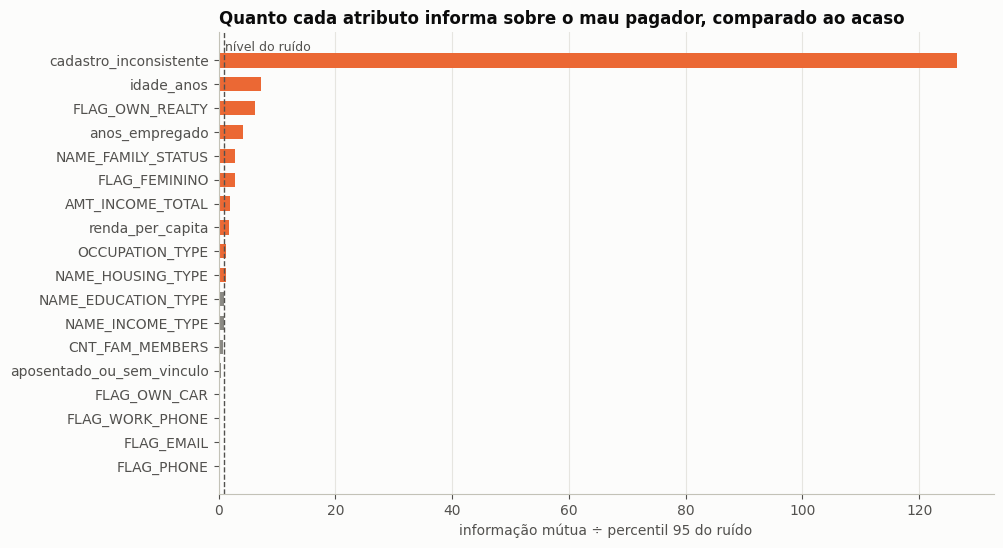

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
cores = [COR_MAU if r > 1 else COR_NEUTRA for r in selecao["razao_sinal_ruido"]]
ax.barh(selecao.index[::-1], selecao["razao_sinal_ruido"][::-1], color=cores[::-1], height=0.6)
ax.axvline(1, color="#52514e", linestyle="--", linewidth=1)
ax.text(1.05, len(selecao) - 0.6, "nível do ruído", fontsize=9, color="#52514e")
ax.set_xlabel("informação mútua ÷ percentil 95 do ruído")
ax.set_title("Quanto cada atributo informa sobre o mau pagador, comparado ao acaso")
ax.grid(axis="y", visible=False)
salvar(fig, "02_selecao_atributos")
plt.show()

**Interpretação:**

- `cadastro_inconsistente` fica **126 vezes acima do ruído**. É um grupo minúsculo, mas
  perfeitamente associado ao alvo (seção 4.1).
- **Sinais mais fortes** entre os atributos originais, de 4 a 7 vezes acima do ruído: **idade**,
  **possuir imóvel** e **tempo de emprego**.
- **Sinais menores, mas acima do ruído:** estado civil e sexo (cerca de 2,9×), renda total e
  per capita (cerca de 1,9×), e ocupação e moradia (cerca de 1,2×).
- **No limite do ruído:** escolaridade (0,95) e tipo de renda (0,93). Na EDA as duas mostraram
  diferenças de taxa, mas concentradas em grupos pequenos (ex.: 374 pessoas com ensino
  fundamental). Além disso, o tipo de renda se sobrepõe à idade e ao tempo de emprego
  (pensionistas). Pela regra adotada, **saem**.
- **Abaixo do ruído:**
  - `aposentado_ou_sem_vinculo`: já está embutido em `anos_empregado = 0`, na idade e em
    `cadastro_inconsistente`.
  - `CNT_FAM_MEMBERS`: já entra via `renda_per_capita`.
  - Indicadores de contato (`FLAG_WORK_PHONE`, `FLAG_PHONE`, `FLAG_EMAIL`) e de carro (`FLAG_OWN_CAR`).

  Todos saem.
- **Ressalva:** a informação mútua avalia uma variável por vez e não enxerga interações. Por isso o
  notebook 03 confere, na validação cruzada, se a lista enxuta perde desempenho em relação a
  todas as candidatas.

**Exclusão por critério ético e regulatório: `FLAG_FEMININO` (sexo).** Mesmo com sinal acima do
ruído, o sexo **não entra no modelo**. Negar ou conceder crédito com base em gênero é
discriminatório, conflita com a LGPD (dado pessoal usado em decisão automatizada que afeta o
titular, art. 20) e é vedado explicitamente em várias jurisdições. Um modelo que precisa do sexo
para funcionar não seria aprovado por uma área de risco ou de compliance. A variável continua
disponível na base, apenas para análises de equidade.

In [15]:
EXCLUSAO_ETICA = ["FLAG_FEMININO"]

selecao["decisao"] = np.where(selecao["razao_sinal_ruido"] > 1, "manter", "remover: abaixo do ruido")
selecao.loc[EXCLUSAO_ETICA, "decisao"] = "remover: criterio etico"
removidas = pd.DataFrame(
    {"tipo": "numerica", "decisao": ["remover: constante", "remover: redundante com CNT_FAM_MEMBERS"]},
    index=pd.Index(["FLAG_MOBIL", "CNT_CHILDREN"], name="atributo"),
)
selecao = pd.concat([selecao, removidas])

METRICS.mkdir(parents=True, exist_ok=True)
selecao.round(6).to_csv(METRICS / "selecao_atributos.csv")

finais = selecao.query("decisao == 'manter'")
print("Atributos selecionados:", len(finais))
finais[["tipo", "razao_sinal_ruido"]].round(2)

Atributos selecionados: 9


,tipo,razao_sinal_ruido
atributo,,
cadastro_inconsistente,numerica,126.43
idade_anos,numerica,7.21
FLAG_OWN_REALTY,numerica,6.31
anos_empregado,numerica,4.18
NAME_FAMILY_STATUS,categorica,2.88
AMT_INCOME_TOTAL,numerica,1.91
renda_per_capita,numerica,1.83
OCCUPATION_TYPE,categorica,1.26
NAME_HOUSING_TYPE,categorica,1.23


**Resultado:** **9 atributos** seguem para a modelagem: 6 numéricos (idade, anos de emprego,
renda total, renda per capita, possui imóvel, cadastro inconsistente) e 3 categóricos (estado
civil, ocupação, moradia). A tabela completa, com a decisão para cada coluna, fica em
`results/metrics/selecao_atributos.csv`. O notebook 03 lê a lista de lá.

## 7. Grupos de perfil

Na EDA, 73% das linhas repetiam exatamente o perfil de outra (mesmo cadastro, IDs diferentes).
No notebook 03, o split e a validação cruzada mantêm cada perfil inteiro de um lado só, para que o
modelo seja sempre testado em clientes que nunca viu.

**Critério do grupo:** linhas com os mesmos valores **nos 9 atributos selecionados** recebem o
mesmo `perfil_id`. O critério precisa ser o que o modelo enxerga. Se o grupo usasse todas as
colunas do cadastro, duas linhas da mesma pessoa que diferem só num campo descartado (ex.:
informou o telefone em um pedido e não no outro) cairiam em grupos diferentes, mas seriam
**idênticas para o modelo**. Uma iria para o treino e a outra para o teste, e o vazamento
continuaria. Num teste preliminar, esse vazamento residual elevava a AUC-ROC de ~0,55 para ~0,60.

In [16]:
df[GROUP] = profile_groups(df, finais.index.tolist())
print("Linhas:", len(df), "| perfis distintos nos atributos do modelo:", df[GROUP].nunique())
df.groupby(GROUP).size().value_counts().sort_index().head(10).rename("perfis com N linhas")

Linhas: 36457 | perfis distintos nos atributos do modelo: 9579


1     3018
2     1560
3     1168
4      888
5      727
6      560
7      428
8      330
9      240
10     175
Name: perfis com N linhas, dtype: int64

## 8. Salvar dataset tratado

O arquivo leva o ID, o grupo de perfil, o alvo e **todas as candidatas**, não só as 9
selecionadas. Assim o notebook 03 pode comparar as duas versões. Ele fica em `data/processed/`,
que não é versionado.

In [17]:
saida = df[["ID", GROUP, TARGET] + candidatas]
save_processed(saida, PROCESSED_FILE)
print(saida.shape)
saida.head()

(36457, 21)


,ID,perfil_id,mau_pagador,FLAG_FEMININO,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,idade_anos,aposentado_ou_sem_vinculo,anos_empregado,cadastro_inconsistente,renda_per_capita
0,5008804,0,0,0,1,1,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,0,0,Nao informado,2.0,32.9,0,12.4,0,213750.0
1,5008805,0,0,0,1,1,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,0,0,Nao informado,2.0,32.9,0,12.4,0,213750.0
2,5008806,1,0,0,1,1,112500.0,Working,Secondary / secondary special,Married,House / apartment,0,0,0,Security staff,2.0,58.8,0,3.1,0,56250.0
3,5008808,2,0,1,0,1,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Sales staff,1.0,52.3,0,8.4,0,270000.0
4,5008809,2,0,1,0,1,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Sales staff,1.0,52.3,0,8.4,0,270000.0
